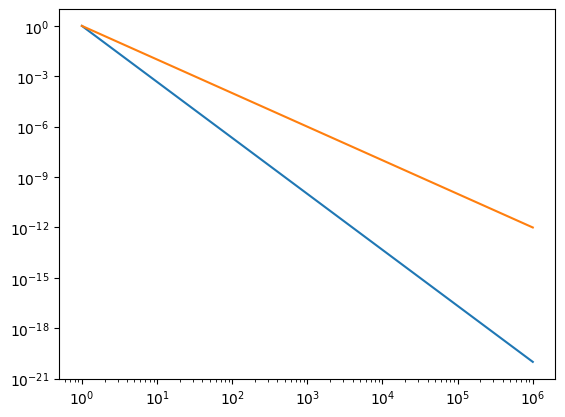

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

class CC85(object):
    def __init__(self, edot, mdot, d_inj,  gamma = 5/3.):
        v_init  = np.sqrt( 2* (gamma-1)/(gamma+1) * edot / mdot )
        rho_init  = mdot / (4 * np.pi* d_inj**2 * v_init)
        p_init = rho_init ** gamma

        self.profile_rho = lambda x: rho_init * (x / d_inj)**(-2)
        self.profile_P = lambda x: p_init * (x / d_inj) ** ( - 2 * gamma)
        self.v_wind = v_init
        
    
wind = CC85(3e41, 2 * u.M_sun.to('g')/u.yr.to('s'), 200 * u.pc.to('cm'))

radius = np.logspace(0, 6, 100)
plt.plot(radius, wind.profile_P(radius)/ wind.profile_P(radius)[0])
plt.plot(radius, wind.profile_rho(radius)/ wind.profile_rho(radius)[0])
plt.xscale('log')
plt.yscale('log')

In [ ]:

class EntrainmentCloud(object):

    def __init__(self, d0, r_cl0, edot, mdot, d_inj, mach, T_cl = 1e4, profile = 'CC85'):


        self.d0 = d0 #kpc
        self.r_cl0 = r_cl0 #pc
        self.T_cl = T_cl
        self.mass0 = 4/3. * (r_cl0 * u.parsec.to('cm') )**3 * np.pi * self.chi(d0) * self.profile_n(d0) * mbar / u.M_sun.to('g')

        if profile == 'CC85':
            mdot_cgs = mdot * u.M_sun.to('g') / u.yr.to('s')
            edot_cgs = edot
            d_inj_cgs = d_inj * u.pc.to('m')
            model = CC85(edot_cgs, mdot_cgs, d_inj_cgs)
            self.profile_P = model.profile_P
            self.profile_n = model.profile_rho / mbar
            
        if tcool == None:  
            self.Lambda_units = 1
            self.tcool0 = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s')
        else:
            self.Lambda_units = get_t_cool_n(T_cl, self.profile_n(d0) * self.chi(d0)) / u.Myr.to('s') / tcool
            self.tcool0 = tcool
        print("This is Tcool0:", self.tcool0)
        Lturb = r_cl0
        f_A = 0.23
        if self.vturb / 1000 > 30: f_A *= 2
        self.tgrow0 = cooling_factor* 35 * (f_A / 0.23)  * (self.chi(d0)/100.) * (self.r_cl0 / 100.) *\
            (Lturb / 100.)**(-0.25) * (self.tcool0 / 0.03 )**(0.25)
        #assert self.tcool0 < (r_cl0 / vturb), f"tgrow0 has to be smaller than tcc: {r_cl0 / vturb} Myr!"
        print("This is gtgrow0:", self.tgrow0 * u.Myr.to('s') * self.profile_g(d0) / 1e2 /1e3)


    def chi(self, d):
        return self.profile_T(d) / self.T_cl

    def rcl(self, d, rfirst = None):
        if rfirst == None: return self.r_cl0* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        else: return rfirst* (self.profile_P(self.d0) / self.profile_P(d))**(1/3.)
        

    def profile_P(self, d):

SyntaxError: incomplete input (132571615.py, line 37)